In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.columns = df.columns.str.strip()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.isnull().sum()
df.dropna(inplace=True)
df.drop("customerID", axis=1, inplace=True)

In [7]:
df["Churn"].value_counts()
(df["Churn"].value_counts(normalize=True)*100)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

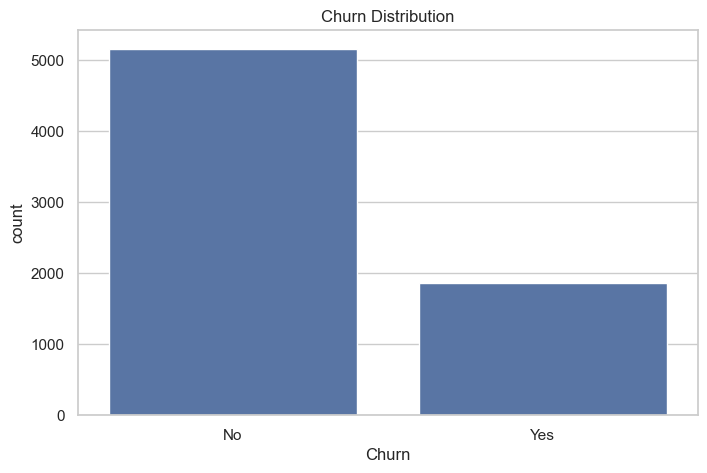

In [8]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

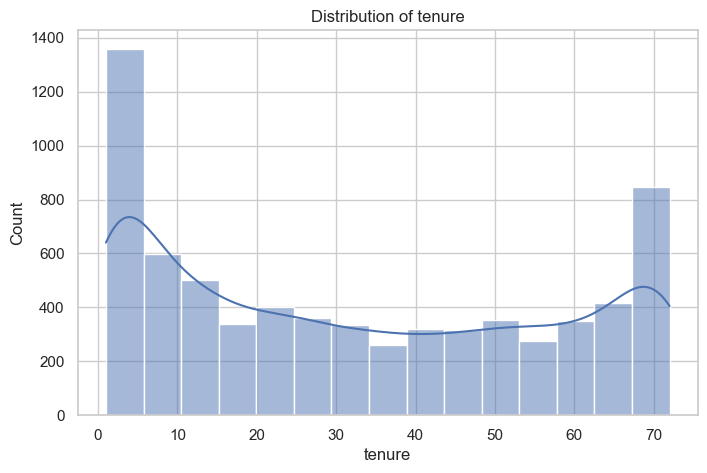

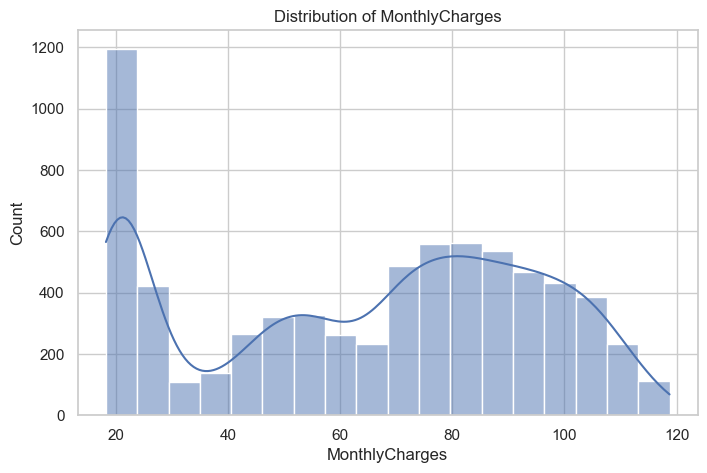

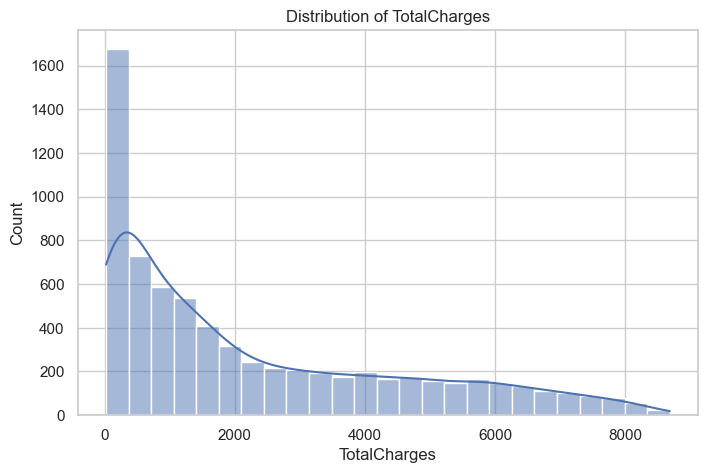

In [9]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

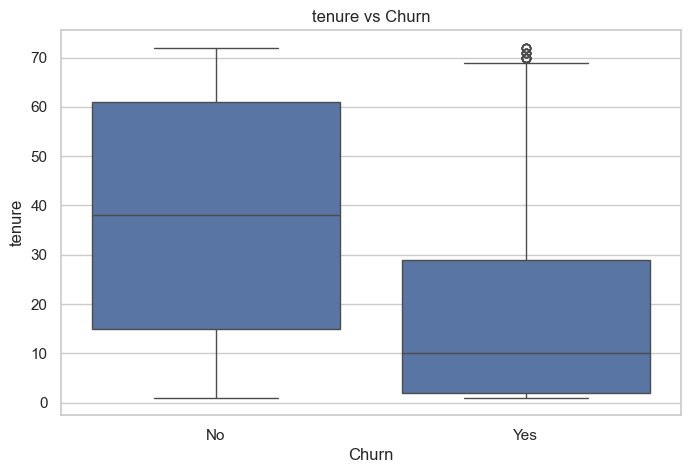

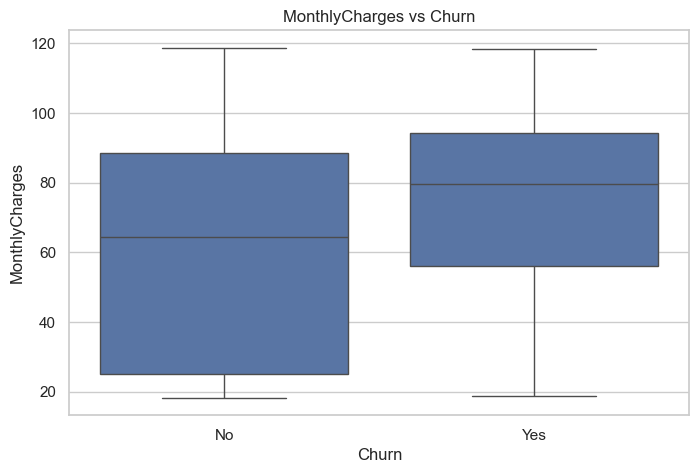

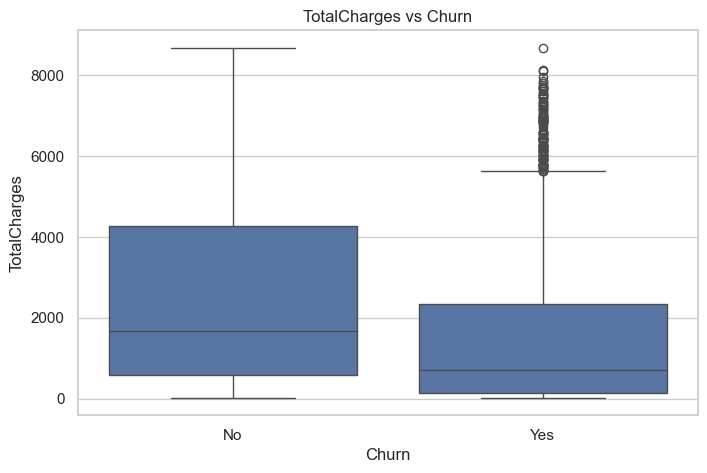

In [10]:
for col in num_cols:
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} vs Churn")
    plt.show()

In [11]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols = cat_cols.drop("Churn")

/var/folders/zm/k5nv23vn5mj5_ztpys45fscr0000gn/T/ipykernel_11854/565976174.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


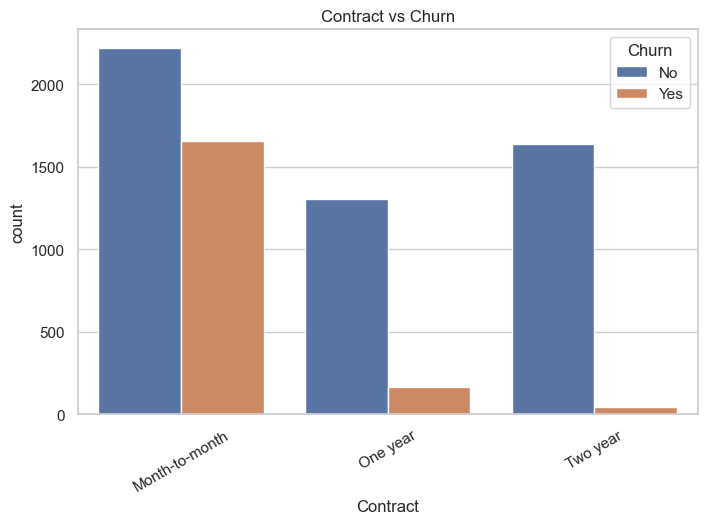

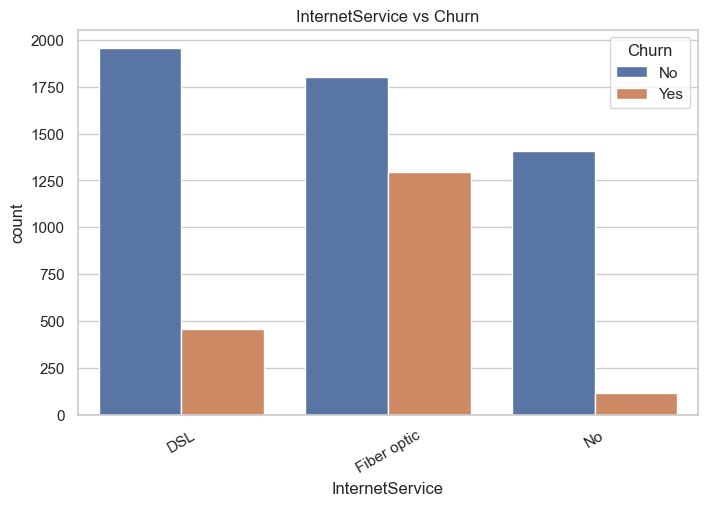

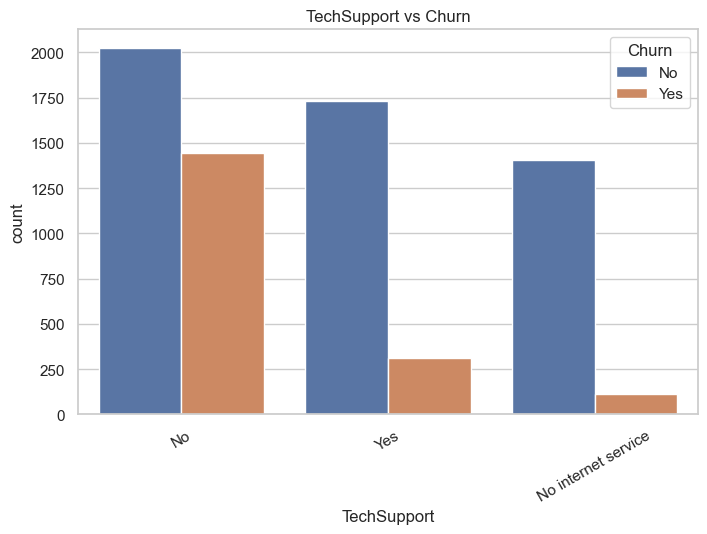

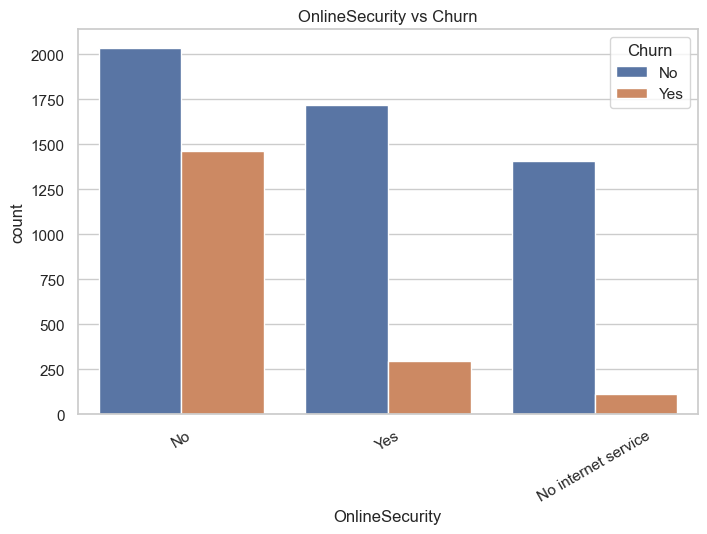

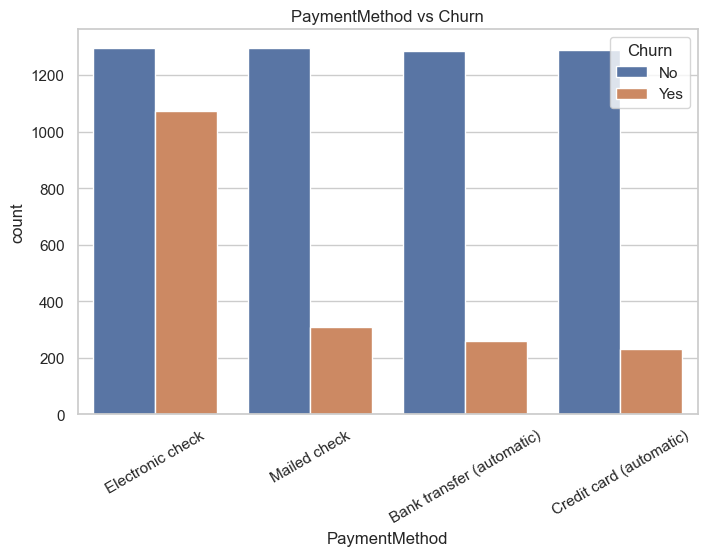

In [12]:
important_cols = [
    "Contract", "InternetService", "TechSupport",
    "OnlineSecurity", "PaymentMethod"
]

for col in important_cols:
    sns.countplot(data=df, x=col, hue="Churn")
    plt.xticks(rotation=30)
    plt.title(f"{col} vs Churn")
    plt.show()

In [ ]:
bins = [0,12,24,36,48,60,72]
labels = ["0-1yr","1-2yr","2-3yr","3-4yr","4-5yr","5+yr"]

df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels)

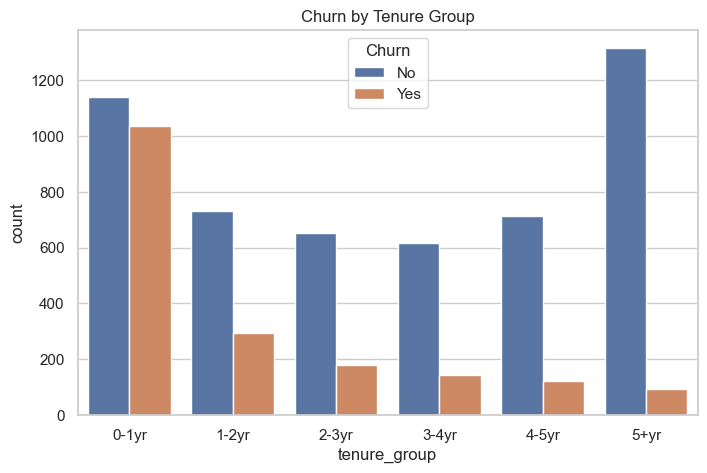

In [14]:
sns.countplot(data=df, x="tenure_group", hue="Churn")
plt.title("Churn by Tenure Group")
plt.show()

In [15]:
df["AvgMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)

df["HighRisk_Contract"] = (df["Contract"] == "Month-to-month").astype(int)

df["NoSupport"] = (
    (df["TechSupport"] == "No") &
    (df["OnlineSecurity"] == "No")
).astype(int)

df["FiberUser"] = (df["InternetService"] == "Fiber optic").astype(int)

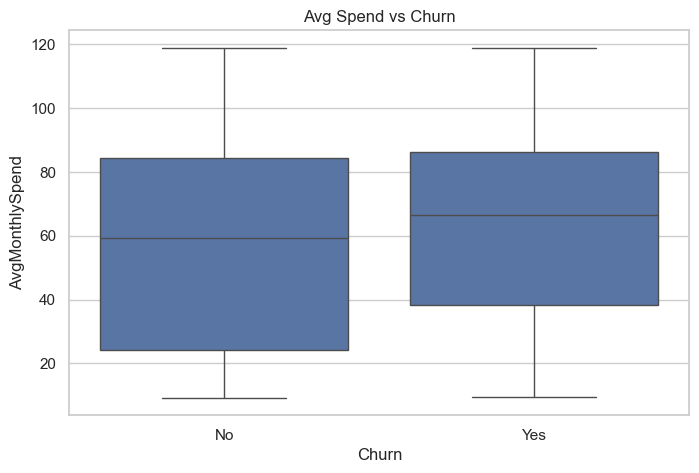

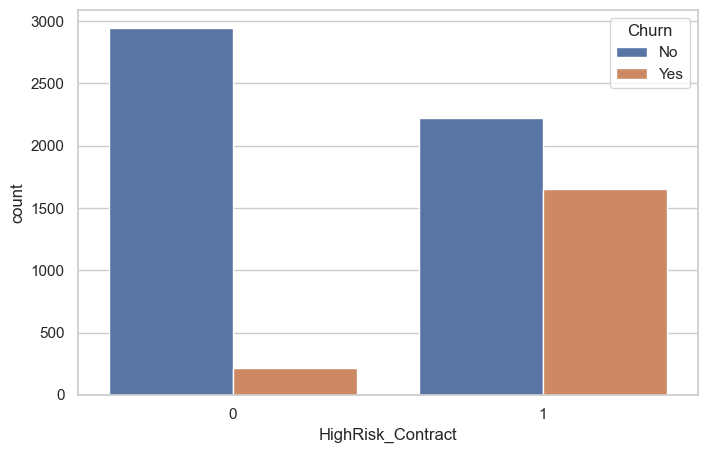

In [16]:
sns.boxplot(data=df, x="Churn", y="AvgMonthlySpend")
plt.title("Avg Spend vs Churn")
plt.show()

sns.countplot(data=df, x="HighRisk_Contract", hue="Churn")
plt.show()

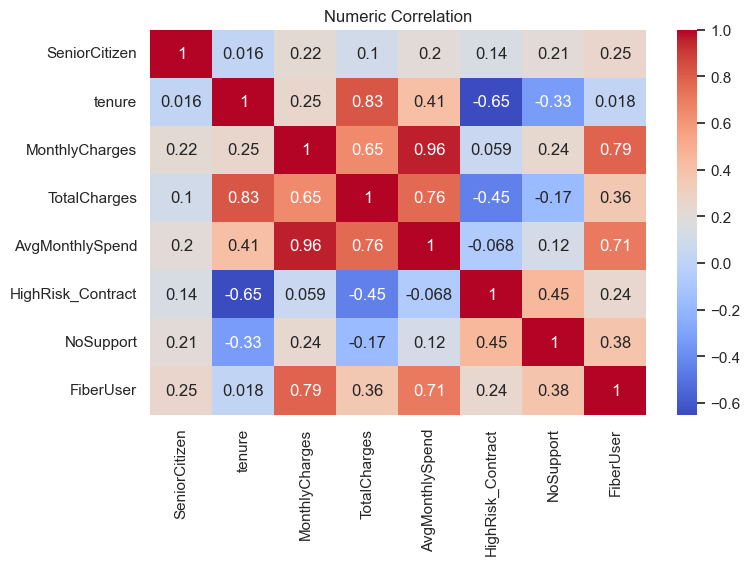

In [17]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Numeric Correlation")
plt.show()

/var/folders/zm/k5nv23vn5mj5_ztpys45fscr0000gn/T/ipykernel_11854/3011614805.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in temp_df.select_dtypes(include=["object", "category"]).columns:


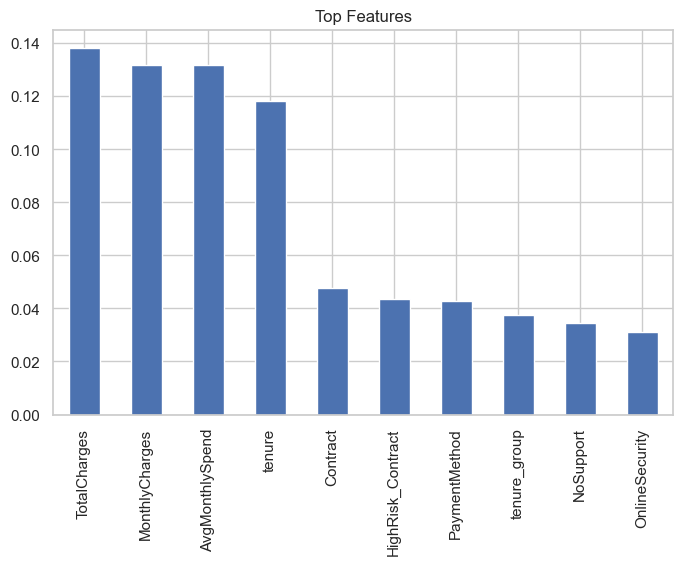

In [ ]:
from sklearn.preprocessing import LabelEncoder
temp_df = df.copy()
for col in temp_df.select_dtypes(include=["object", "category"]).columns:
    temp_df[col] = LabelEncoder().fit_transform(temp_df[col])

X = temp_df.drop("Churn", axis=1)
y = temp_df["Churn"]

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Features")
plt.show()


* Contract = Month-to-month → highest churn risk
* Low tenure (new customers) → churn spikes early
* No TechSupport / No OnlineSecurity → clear churn drivers
* High MonthlyCharges → increases churn likelihood
* Fiber optic users → higher churn than DSL

Weak or irrelevant features

* Gender
* PhoneService
* MultipleLines

High MonthlyCharges + Low Tenure + Month-to-month contract

→ Highest churn segment

IF customer is:

- new (low tenure)

- expensive (high monthly charges)

- flexible contract (month-to-month)

- low support services

THEN → high churn probability

1. Customer churn is highest among new customers with flexible (month-to-month) contracts.

2. Customers lacking support services (TechSupport, OnlineSecurity) are more likely to churn.

3. High monthly charges significantly increase churn probability, especially in early tenure.

4. Retention improves strongly with long-term contracts and longer tenure.

5. Some features like gender and phone service show negligible impact on churn behavior.